In [4]:
### Cell 1：导入和加载模型
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False  # 防止负号也变方块

# 加载模型结构
model = models.resnet18()
model.fc = nn.Linear(512, 7)

# 加载训练好的参数
model.load_state_dict(torch.load('emotion_model.pth'))
model.eval()  # 切换到预测模式

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 预处理（和训练时一致，但不加随机翻转）
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# 7类情绪（按字母顺序，和训练时 ImageFolder 自动排序一致）
classes_en = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
classes_cn = ['生气',   '厌恶',    '害怕',  '开心',   '平静',    '难过',  '惊讶']

print("模型加载完成，可以开始预测了")

C:\Users\29208\AppData\Local\Temp\ipykernel_81804\1237705343.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('emotion_model.pth'))


模型加载完成，可以开始预测了


预测情绪: 害怕（fear）
置信度: 98.0%

所有情绪概率：
  生气 (angry   ):   1.1%  
  厌恶 (disgust ):   0.0%  
  害怕 (fear    ):  98.0%  █████████████████████████████
  开心 (happy   ):   0.5%  
  平静 (neutral ):   0.0%  
  难过 (sad     ):   0.1%  
  惊讶 (surprise):   0.2%  


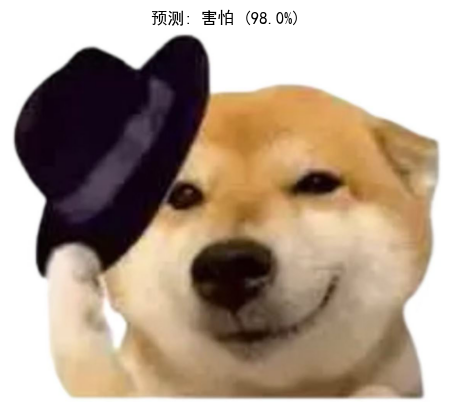

In [39]:
### Cell 2：测试单张图片
# 改成你想测试的图片路径
image_path = './data/emotion/val/happy/happy_1.jpg'

image = Image.open(image_path)
img_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)[0]  # 转成概率（7个数加起来=1）

pred_idx = probs.argmax().item()

# 显示结果
print(f"预测情绪: {classes_cn[pred_idx]}（{classes_en[pred_idx]}）")
print(f"置信度: {probs[pred_idx].item()*100:.1f}%\n")

print("所有情绪概率：")
for cn, en, prob in zip(classes_cn, classes_en, probs):
    bar = '█' * int(prob.item() * 30)
    print(f"  {cn} ({en:8s}): {prob.item()*100:5.1f}%  {bar}")

plt.imshow(image, cmap='gray')
plt.title(f"预测: {classes_cn[pred_idx]} ({probs[pred_idx].item()*100:.1f}%)")
plt.axis('off')
plt.show()